# Analisis Pengujian: Q-Learning vs Q-Learning Crisp vs Q-Learning Fuzzy vs HPA

Analisis komparatif hasil pengujian empat metode autoscaling.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

DATA_DIR = 'data/testing/60-episodes'

# One run each: pick 1 q, 1 qcrisp, 1 qfuzzy (from run folder '1') and 1 hpa
FILES = {
    'ql':     f'{DATA_DIR}/1/test_qlearning_20260807_143047.csv',
    'qcrisp': f'{DATA_DIR}/1/test_qlearningcrisp_20260807_142854.csv',
    'qfuzzy': f'{DATA_DIR}/1/test_qlearningfuzzy_20260807_142708.csv',
    'hpa':    f'{DATA_DIR}/hpa/metrics_20260807_162124.csv',
}

# Method order, colors and labels
METHODS = ['ql', 'qcrisp', 'qfuzzy', 'hpa']
COLORS = {'ql': '#26A69A', 'qcrisp': '#EC407A', 'qfuzzy': '#5C6BC0', 'hpa': '#FF7043'}
LABELS = {'ql': 'Q-Learning', 'qcrisp': 'Q-Learning Crisp', 'qfuzzy': 'Q-Learning Fuzzy', 'hpa': 'HPA'}

# Load data
dfs = {k: pd.read_csv(path, parse_dates=['timestamp']) for k, path in FILES.items()}

print('Raw row counts:')
for k in METHODS:
    print(f'  {LABELS[k]:<20}: {len(dfs[k])} rows')

# Trim all datasets to the smallest row count for fair comparison
min_rows = min(len(dfs[k]) for k in METHODS)
for k in METHODS:
    dfs[k] = dfs[k].iloc[:min_rows].reset_index(drop=True)
print(f'\nTrimmed to {min_rows} rows (smallest dataset)')

# Use elapsed time (seconds from start) for x-axis alignment
for k in METHODS:
    dfs[k]['elapsed_s'] = (dfs[k]['timestamp'] - dfs[k]['timestamp'].iloc[0]).dt.total_seconds()

print('\nAfter trimming:')
for k in METHODS:
    print(f'  {LABELS[k]:<20}: {len(dfs[k])} rows, {dfs[k]["elapsed_s"].iloc[-1]:.0f}s duration')

# Convenience list used by every plotting cell
datasets = [(k, dfs[k], LABELS[k]) for k in METHODS]

Raw row counts:
  Q-Learning          : 117 rows
  Q-Learning Crisp    : 124 rows
  Q-Learning Fuzzy    : 120 rows
  HPA                 : 92 rows

Trimmed to 92 rows (smallest dataset)

After trimming:
  Q-Learning          : 92 rows, 1515s duration
  Q-Learning Crisp    : 92 rows, 1498s duration
  Q-Learning Fuzzy    : 92 rows, 1490s duration
  HPA                 : 92 rows, 1947s duration


## 6.1.7 Hasil SLO Response Time Selama Pengujian

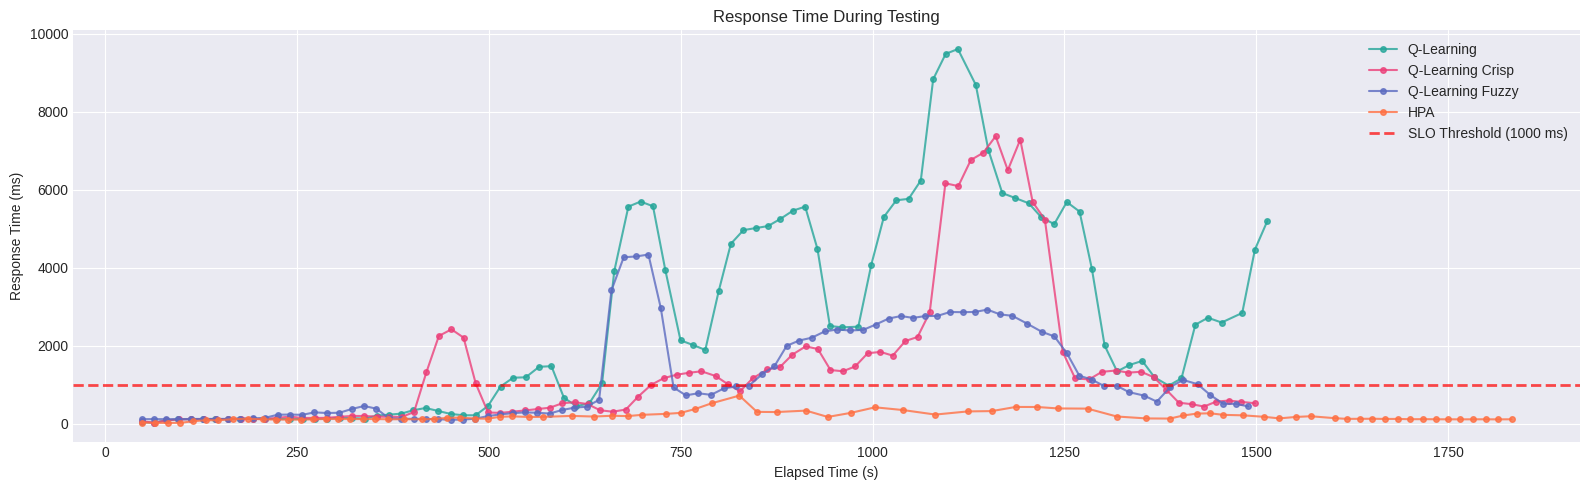

                    Response Time Statistics (ms)                     
----------------------------------------------------------------------
Method                        Mean   Median      Min      Max      Std
----------------------------------------------------------------------
Q-Learning                  2697.3   1896.2     32.5   9606.8   2599.4
Q-Learning Crisp            1428.1    870.1     29.4   7372.5   1835.3
Q-Learning Fuzzy            1199.5    740.1    106.7   4340.4   1168.5
HPA                          192.7    141.0     26.2    725.6    119.0


In [12]:
SLO_THRESHOLD = 1000  # ms

# --- Response Time Line Chart ---
fig, ax = plt.subplots(figsize=(16, 5))

for key, df, label in datasets:
    mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    ax.plot(df.loc[mask, 'elapsed_s'], df.loc[mask, 'response_time_ms'],
            marker='o', markersize=4, linewidth=1.5, label=label, color=COLORS[key], alpha=0.8)

ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'SLO Threshold ({SLO_THRESHOLD} ms)')
ax.set_xlabel('Elapsed Time (s)')
ax.set_ylabel('Response Time (ms)')
ax.set_title('Response Time During Testing')
ax.legend()

plt.tight_layout()
plt.show()

# Response Time Statistics
print(f'{"Response Time Statistics (ms)":^70}')
print(f'{"-" * 70}')
print(f'{"Method":<25} {"Mean":>8} {"Median":>8} {"Min":>8} {"Max":>8} {"Std":>8}')
print(f'{"-" * 70}')
for key, df, label in datasets:
    valid = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms']
    if len(valid) > 0:
        print(f'{label:<25} {valid.mean():>8.1f} {valid.median():>8.1f} {valid.min():>8.1f} {valid.max():>8.1f} {valid.std():>8.1f}')
    else:
        print(f'{label:<25} {"N/A":>8} {"N/A":>8} {"N/A":>8} {"N/A":>8} {"N/A":>8}')

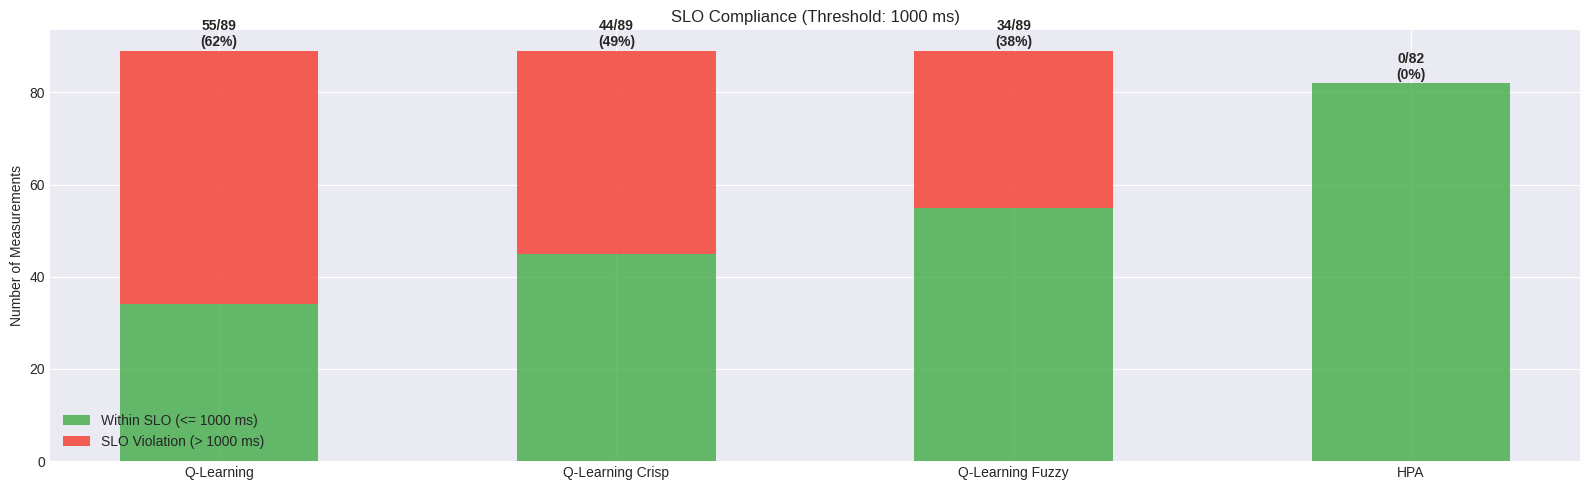


                      SLO RESPONSE TIME SUMMARY                       
Method                       Total   Within SLO   Violations  Violation %
----------------------------------------------------------------------
Q-Learning                      89           34           55        61.8%
Q-Learning Crisp                89           45           44        49.4%
Q-Learning Fuzzy                89           55           34        38.2%
HPA                             82           82            0         0.0%


In [13]:
# --- SLO Violation Count ---
fig, ax = plt.subplots(figsize=(16, 5))

violations = {}
totals = {}
for key, df, label in datasets:
    valid = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    total = valid.sum()
    over_slo = (df.loc[valid, 'response_time_ms'] > SLO_THRESHOLD).sum()
    violations[label] = over_slo
    totals[label] = total

labels_list = list(violations.keys())
violation_counts = list(violations.values())
total_counts = [totals[l] for l in labels_list]
within_counts = [t - v for t, v in zip(total_counts, violation_counts)]

x = np.arange(len(labels_list))
width = 0.5

ax.bar(x, within_counts, width, label=f'Within SLO (<= {SLO_THRESHOLD} ms)', color='#4CAF50', alpha=0.85)
ax.bar(x, violation_counts, width, bottom=within_counts, label=f'SLO Violation (> {SLO_THRESHOLD} ms)', color='#F44336', alpha=0.85)

for i, (v, t) in enumerate(zip(violation_counts, total_counts)):
    pct = v / t * 100 if t > 0 else 0
    ax.text(i, t + 0.3, f'{v}/{t}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Number of Measurements')
ax.set_title(f'SLO Compliance (Threshold: {SLO_THRESHOLD} ms)')
ax.set_xticks(x)
ax.set_xticklabels(labels_list)
ax.legend()

plt.tight_layout()
plt.show()

# SLO Summary Table
print(f'\n{"=" * 70}')
print(f'{"SLO RESPONSE TIME SUMMARY":^70}')
print(f'{"=" * 70}')
print(f'{"Method":<25} {"Total":>8} {"Within SLO":>12} {"Violations":>12} {"Violation %":>12}')
print(f'{"-" * 70}')
for label in labels_list:
    t = totals[label]
    v = violations[label]
    w = t - v
    pct = v / t * 100 if t > 0 else 0
    print(f'{label:<25} {t:>8} {w:>12} {v:>12} {pct:>11.1f}%')

## 6.1.8 Hasil Utilisasi CPU dan Memori Selama Pengujian

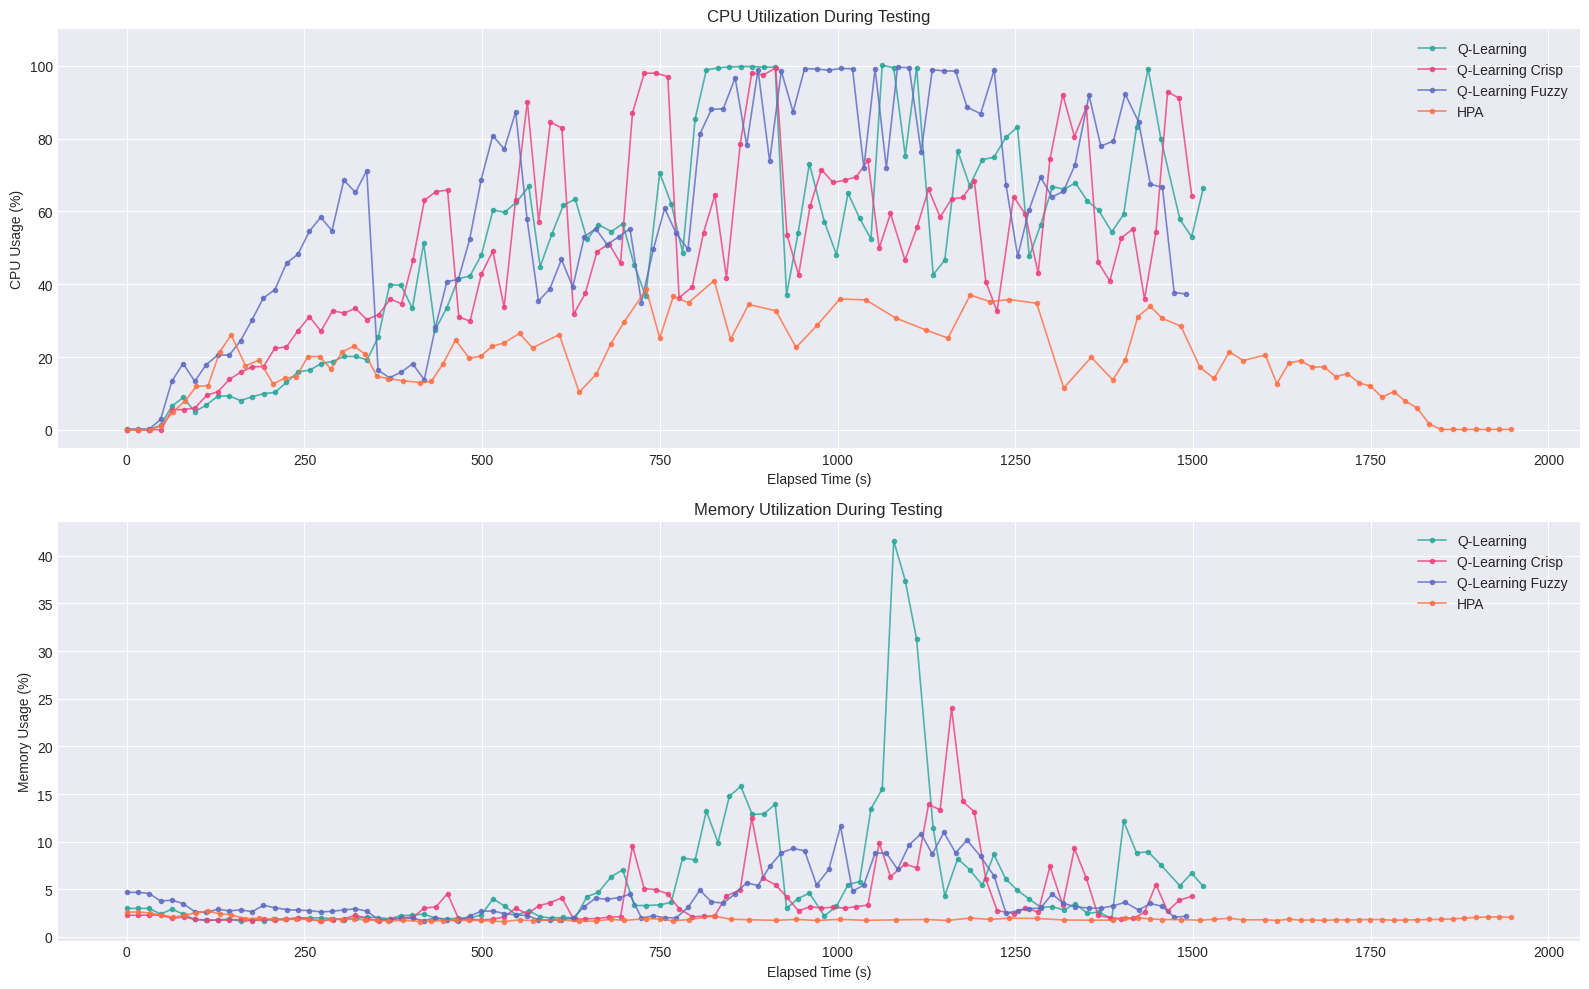


                   CPU & MEMORY UTILIZATION SUMMARY                   

                            CPU Usage (%)                             
----------------------------------------------------------------------
Method                        Mean   Median      Min      Max      Std
----------------------------------------------------------------------
Q-Learning                   51.02    54.16    0.060   100.16    29.14
Q-Learning Crisp             50.23    49.54    0.050    99.39    26.65
Q-Learning Fuzzy             59.24    60.62    0.177    99.57    29.22
HPA                          18.61    19.03    0.068    41.01    10.81

                           Memory Usage (%)                           
----------------------------------------------------------------------
Method                        Mean   Median      Min      Max      Std
----------------------------------------------------------------------
Q-Learning                    5.83     3.19    1.669    41.57     6.86
Q-L

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Top: CPU Usage ---
ax = axes[0]
for key, df, label in datasets:
    ax.plot(df['elapsed_s'], df['cpu_usage'], marker='o', markersize=3, linewidth=1.2,
            label=label, color=COLORS[key], alpha=0.8)

ax.set_xlabel('Elapsed Time (s)')
ax.set_ylabel('CPU Usage (%)')
ax.set_title('CPU Utilization During Testing')
ax.set_ylim(-5, 110)
ax.legend()

# --- Bottom: Memory Usage ---
ax = axes[1]
for key, df, label in datasets:
    ax.plot(df['elapsed_s'], df['memory_usage'], marker='o', markersize=3, linewidth=1.2,
            label=label, color=COLORS[key], alpha=0.8)

ax.set_xlabel('Elapsed Time (s)')
ax.set_ylabel('Memory Usage (%)')
ax.set_title('Memory Utilization During Testing')
ax.legend()

plt.tight_layout()
plt.show()

# Summary statistics
print(f'\n{"=" * 70}')
print(f'{"CPU & MEMORY UTILIZATION SUMMARY":^70}')
print(f'{"=" * 70}')
print(f'\n{"CPU Usage (%)":^70}')
print(f'{"-" * 70}')
print(f'{"Method":<25} {"Mean":>8} {"Median":>8} {"Min":>8} {"Max":>8} {"Std":>8}')
print(f'{"-" * 70}')
for key, df, label in datasets:
    cpu = df['cpu_usage']
    print(f'{label:<25} {cpu.mean():>8.2f} {cpu.median():>8.2f} {cpu.min():>8.3f} {cpu.max():>8.2f} {cpu.std():>8.2f}')

print(f'\n{"Memory Usage (%)":^70}')
print(f'{"-" * 70}')
print(f'{"Method":<25} {"Mean":>8} {"Median":>8} {"Min":>8} {"Max":>8} {"Std":>8}')
print(f'{"-" * 70}')
for key, df, label in datasets:
    mem = df['memory_usage']
    print(f'{label:<25} {mem.mean():>8.2f} {mem.median():>8.2f} {mem.min():>8.3f} {mem.max():>8.2f} {mem.std():>8.2f}')

## 6.1.9 Hasil Jumlah Replica Selama Pengujian

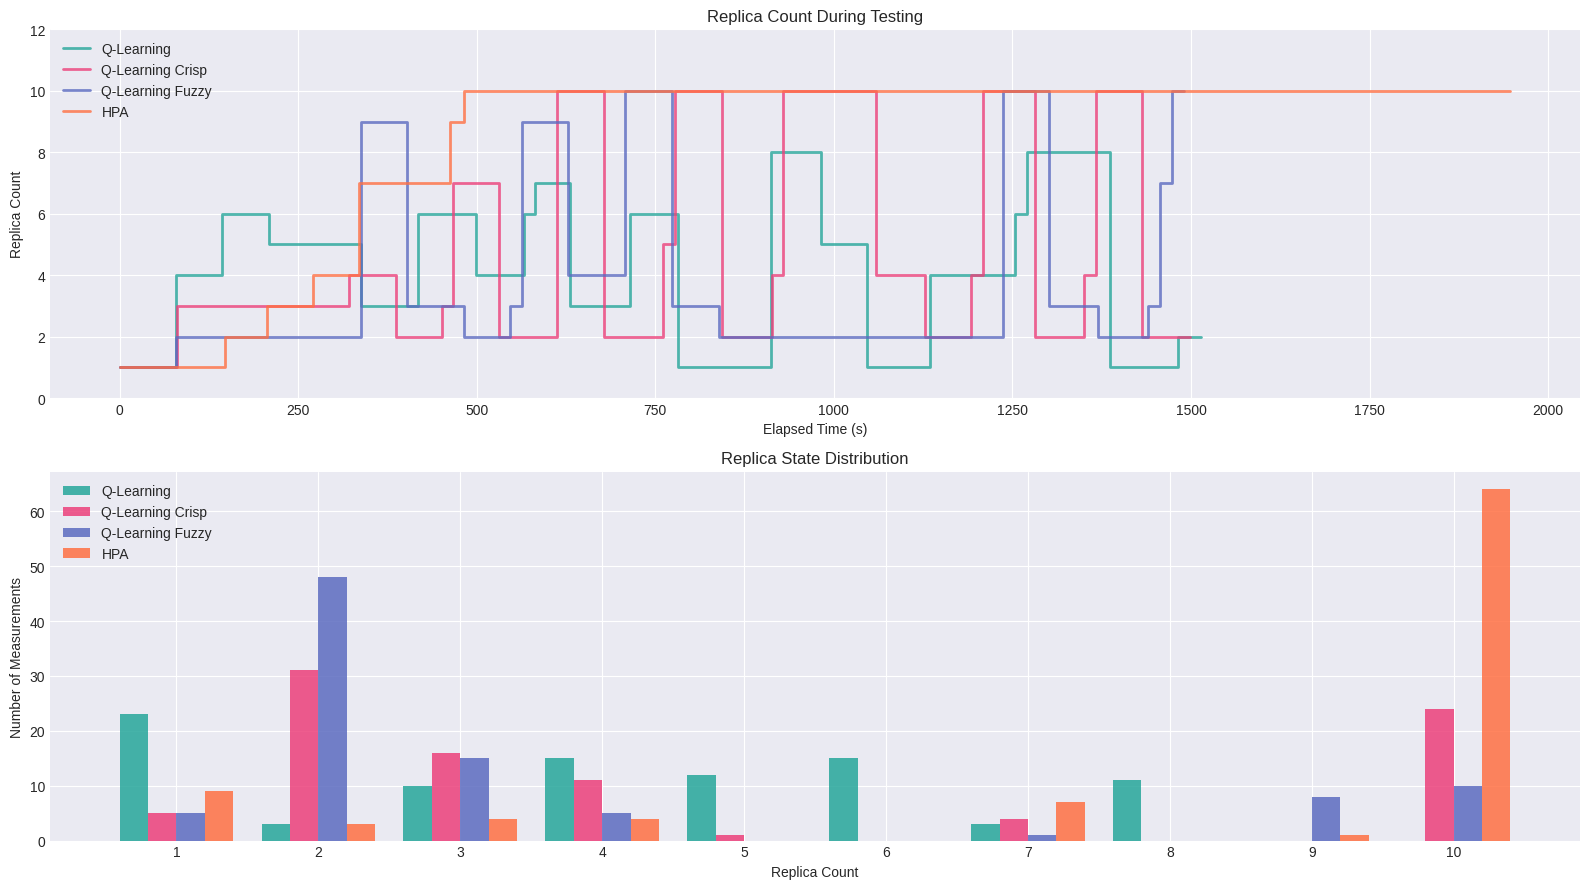


                        REPLICA COUNT SUMMARY                         
Method                        Mean    Min    Max   Mode  Changes
----------------------------------------------------------------------
Q-Learning                    4.11      1      8      1       19
Q-Learning Crisp              4.70      1     10      2       21
Q-Learning Fuzzy              3.75      1     10      2       16
HPA                           8.05      1     10     10        6


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# --- Top: Replica count over time ---
ax = axes[0]
for key, df, label in datasets:
    ax.step(df['elapsed_s'], df['replica_state'], where='post', linewidth=2,
            label=label, color=COLORS[key], alpha=0.8)

ax.set_xlabel('Elapsed Time (s)')
ax.set_ylabel('Replica Count')
ax.set_title('Replica Count During Testing')
ax.set_ylim(0, max(df['replica_state'].max() for _, df, _ in datasets) + 2)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend()

# --- Bottom: Replica distribution bar chart ---
ax = axes[1]
all_replicas = sorted(set().union(*[set(df['replica_state'].unique()) for _, df, _ in datasets]))
x = np.arange(len(all_replicas))
n = len(datasets)
width = 0.8 / n

for i, (key, df, label) in enumerate(datasets):
    counts = df['replica_state'].value_counts().sort_index()
    vals = [counts.get(r, 0) for r in all_replicas]
    ax.bar(x + (i - (n - 1) / 2) * width, vals, width, label=label, color=COLORS[key], alpha=0.85)

ax.set_xlabel('Replica Count')
ax.set_ylabel('Number of Measurements')
ax.set_title('Replica State Distribution')
ax.set_xticks(x)
ax.set_xticklabels(all_replicas)
ax.legend()

plt.tight_layout()
plt.show()

# Summary
print(f'\n{"=" * 70}')
print(f'{"REPLICA COUNT SUMMARY":^70}')
print(f'{"=" * 70}')
print(f'{"Method":<25} {"Mean":>8} {"Min":>6} {"Max":>6} {"Mode":>6} {"Changes":>8}')
print(f'{"-" * 70}')
for key, df, label in datasets:
    rep = df['replica_state']
    changes = (rep.diff().fillna(0) != 0).sum()
    print(f'{label:<25} {rep.mean():>8.2f} {rep.min():>6} {rep.max():>6} {rep.mode().iloc[0]:>6} {changes:>8}')

## 6.1.10 Analisis Efisiensi Sumber Daya: Overprovisioning vs Underprovisioning

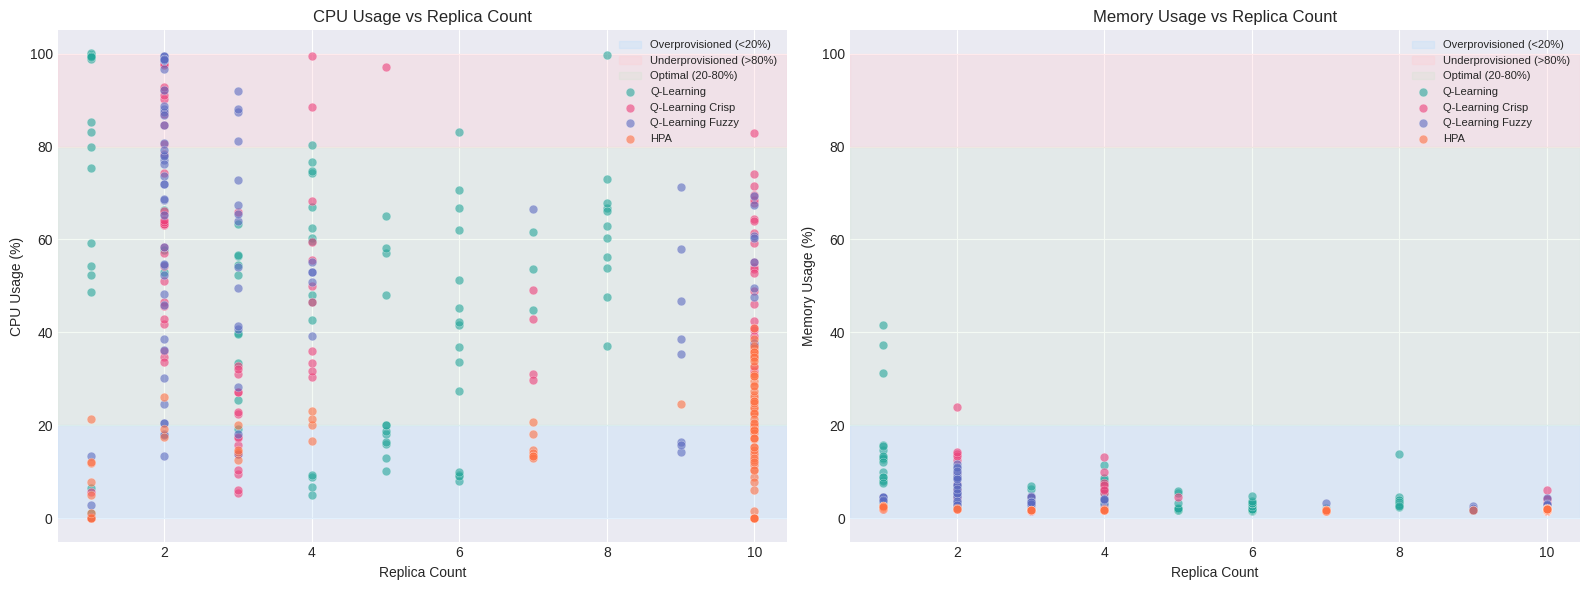

/tmp/ipykernel_17391/1255988056.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.5)
/tmp/ipykernel_17391/1255988056.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.5)


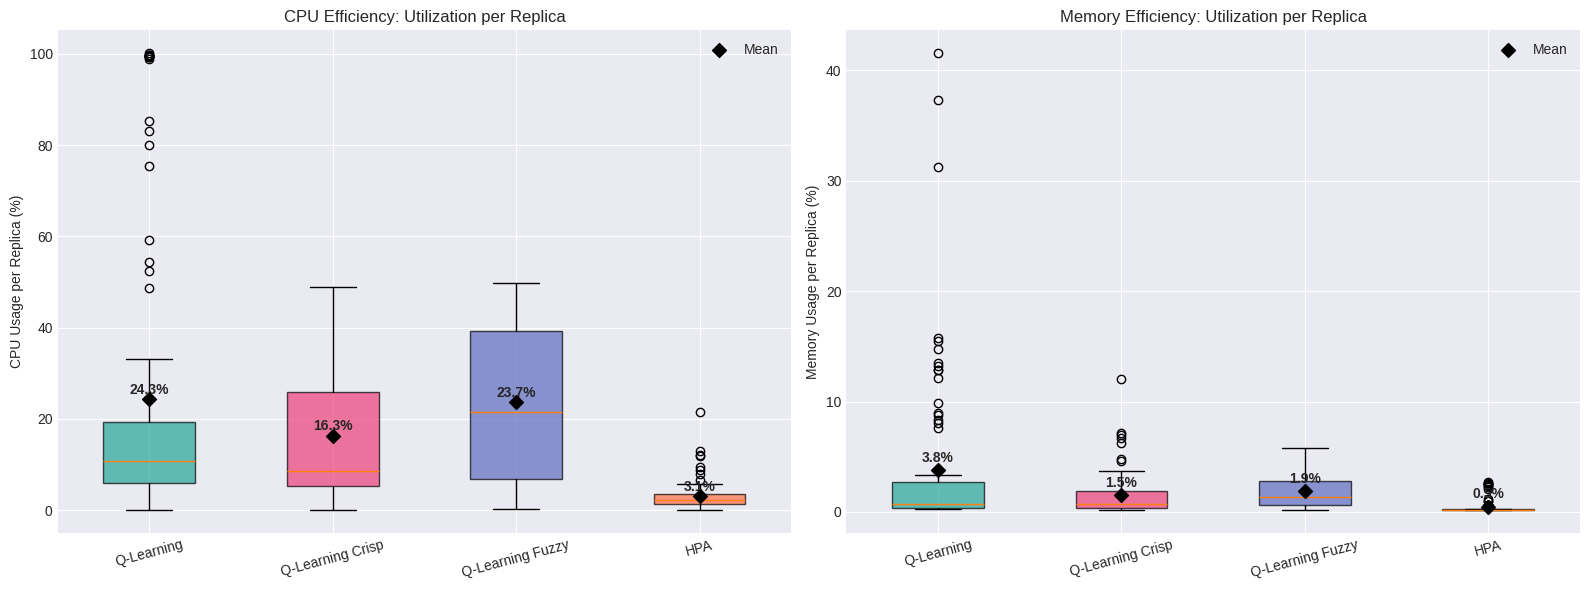

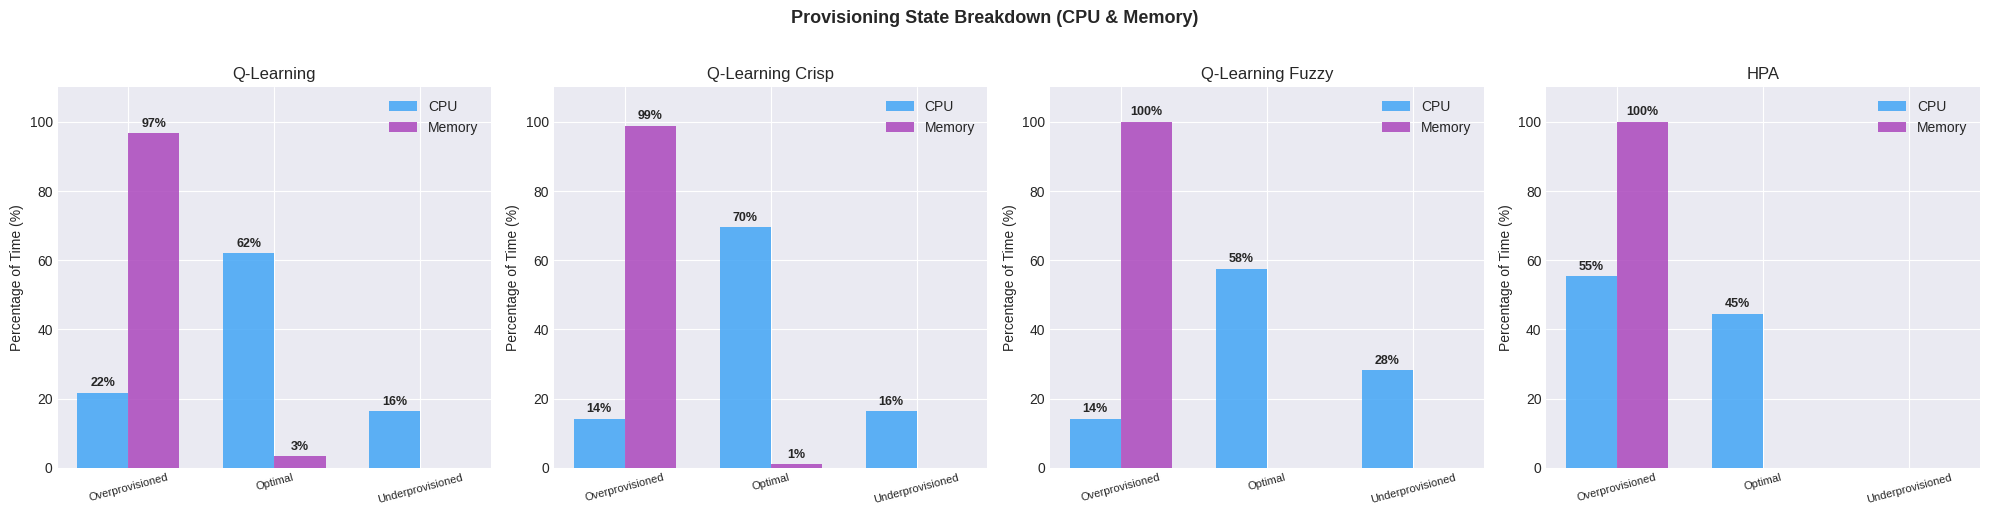


                          RESOURCE EFFICIENCY SUMMARY                           

Method                Avg Replica   Avg CPU   Avg MEM   CPU/Rep   MEM/Rep
--------------------------------------------------------------------------------
Q-Learning                   4.11    51.02%     5.83%    12.42%     1.42%
Q-Learning Crisp             4.70    50.23%     4.02%    10.70%     0.86%
Q-Learning Fuzzy             3.75    59.24%     4.16%    15.80%     1.11%
HPA                          8.05    18.61%     1.89%     2.31%     0.23%

                             Provisioning Breakdown                             
--------------------------------------------------------------------------------
Method                Over (CPU)   Opt (CPU)  Under (CPU)  Over (MEM)   Opt (MEM)  Under (MEM)
--------------------------------------------------------------------------------
Q-Learning                 21.7%       62.0%        16.3%       96.7%        3.3%         0.0%
Q-Learning Crisp           14.1%

In [16]:
# Overprovisioning/Underprovisioning thresholds
CPU_LOW, CPU_HIGH = 20, 80   # from .env MIN_CPU, MAX_CPU
MEM_LOW, MEM_HIGH = 20, 80   # from .env MIN_MEMORY, MAX_MEMORY

# --- 1) CPU & Memory vs Replica (scatter) with provisioning zones ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, label_y in zip(axes, ['cpu_usage', 'memory_usage'], ['CPU Usage (%)', 'Memory Usage (%)']):
    # Shaded zones
    ax.axhspan(0, CPU_LOW, color='#BBDEFB', alpha=0.3, label=f'Overprovisioned (<{CPU_LOW}%)')
    ax.axhspan(CPU_HIGH, 100, color='#FFCDD2', alpha=0.3, label=f'Underprovisioned (>{CPU_HIGH}%)')
    ax.axhspan(CPU_LOW, CPU_HIGH, color='#C8E6C9', alpha=0.2, label=f'Optimal ({CPU_LOW}-{CPU_HIGH}%)')

    for key, df, label in datasets:
        ax.scatter(df['replica_state'], df[metric], s=40, alpha=0.6,
                   color=COLORS[key], label=label, edgecolors='white', linewidth=0.3)

    ax.set_xlabel('Replica Count')
    ax.set_ylabel(label_y)
    ax.set_title(f'{label_y.split(" (")[0]} vs Replica Count')
    ax.set_ylim(-5, 105)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# --- 2) Utilisasi per Replica (efisiensi) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title in zip(axes, ['cpu_usage', 'memory_usage'], ['CPU', 'Memory']):
    bp_data = [dfs[k][metric] / dfs[k]['replica_state'] for k in METHODS]
    bp_labels = [LABELS[k] for k in METHODS]
    bp_colors = [COLORS[k] for k in METHODS]

    bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], bp_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Mean markers
    means = [d.mean() for d in bp_data]
    ax.scatter(range(1, len(METHODS) + 1), means, color='black', marker='D', s=50, zorder=5, label='Mean')
    for i, m in enumerate(means):
        ax.text(i + 1, m + 0.5, f'{m:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel(f'{title} Usage per Replica (%)')
    ax.set_title(f'{title} Efficiency: Utilization per Replica')
    ax.tick_params(axis='x', labelrotation=15)
    ax.legend()

plt.tight_layout()
plt.show()

# --- 3) Provisioning category breakdown per method ---
fig, axes = plt.subplots(1, len(METHODS), figsize=(20, 5))

for ax, (key, df, label) in zip(axes, datasets):
    over_cpu = (df['cpu_usage'] < CPU_LOW).sum()
    optimal_cpu = ((df['cpu_usage'] >= CPU_LOW) & (df['cpu_usage'] <= CPU_HIGH)).sum()
    under_cpu = (df['cpu_usage'] > CPU_HIGH).sum()

    over_mem = (df['memory_usage'] < MEM_LOW).sum()
    optimal_mem = ((df['memory_usage'] >= MEM_LOW) & (df['memory_usage'] <= MEM_HIGH)).sum()
    under_mem = (df['memory_usage'] > MEM_HIGH).sum()

    categories = ['Overprovisioned', 'Optimal', 'Underprovisioned']
    x = np.arange(len(categories))
    width = 0.35

    total = len(df)
    cpu_pcts = [over_cpu/total*100, optimal_cpu/total*100, under_cpu/total*100]
    mem_pcts = [over_mem/total*100, optimal_mem/total*100, under_mem/total*100]

    bars1 = ax.bar(x - width/2, cpu_pcts, width, label='CPU', color='#42A5F5', alpha=0.85)
    bars2 = ax.bar(x + width/2, mem_pcts, width, label='Memory', color='#AB47BC', alpha=0.85)

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2., h + 1,
                    f'{h:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_ylabel('Percentage of Time (%)')
    ax.set_title(f'{label}')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=8, rotation=15)
    ax.set_ylim(0, 110)
    ax.legend()

fig.suptitle('Provisioning State Breakdown (CPU & Memory)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- 4) Summary Table ---
print(f'\n{"=" * 80}')
print(f'{"RESOURCE EFFICIENCY SUMMARY":^80}')
print(f'{"=" * 80}')
print(f'\n{"Method":<20} {"Avg Replica":>12} {"Avg CPU":>9} {"Avg MEM":>9} {"CPU/Rep":>9} {"MEM/Rep":>9}')
print(f'{"-" * 80}')
for key, df, label in datasets:
    avg_rep = df['replica_state'].mean()
    avg_cpu = df['cpu_usage'].mean()
    avg_mem = df['memory_usage'].mean()
    cpu_per_rep = avg_cpu / avg_rep if avg_rep > 0 else 0
    mem_per_rep = avg_mem / avg_rep if avg_rep > 0 else 0
    print(f'{label:<20} {avg_rep:>12.2f} {avg_cpu:>8.2f}% {avg_mem:>8.2f}% {cpu_per_rep:>8.2f}% {mem_per_rep:>8.2f}%')

print(f'\n{"Provisioning Breakdown":^80}')
print(f'{"-" * 80}')
print(f'{"Method":<20} {"Over (CPU)":>11} {"Opt (CPU)":>11} {"Under (CPU)":>12} {"Over (MEM)":>11} {"Opt (MEM)":>11} {"Under (MEM)":>12}')
print(f'{"-" * 80}')
for key, df, label in datasets:
    t = len(df)
    oc = (df['cpu_usage'] < CPU_LOW).sum()
    optc = ((df['cpu_usage'] >= CPU_LOW) & (df['cpu_usage'] <= CPU_HIGH)).sum()
    uc = (df['cpu_usage'] > CPU_HIGH).sum()
    om = (df['memory_usage'] < MEM_LOW).sum()
    optm = ((df['memory_usage'] >= MEM_LOW) & (df['memory_usage'] <= MEM_HIGH)).sum()
    um = (df['memory_usage'] > MEM_HIGH).sum()
    print(f'{label:<20} {oc/t*100:>10.1f}% {optc/t*100:>10.1f}% {uc/t*100:>11.1f}% {om/t*100:>10.1f}% {optm/t*100:>10.1f}% {um/t*100:>11.1f}%')

## 6.1.11 Load Pattern vs Replica & Response Time Selama Pengujian

Visualisasi gabungan yang menunjukkan bagaimana pola beban (k6 VUs) memengaruhi jumlah replica dan response time untuk keempat metode autoscaling selama ~30 menit pengujian.

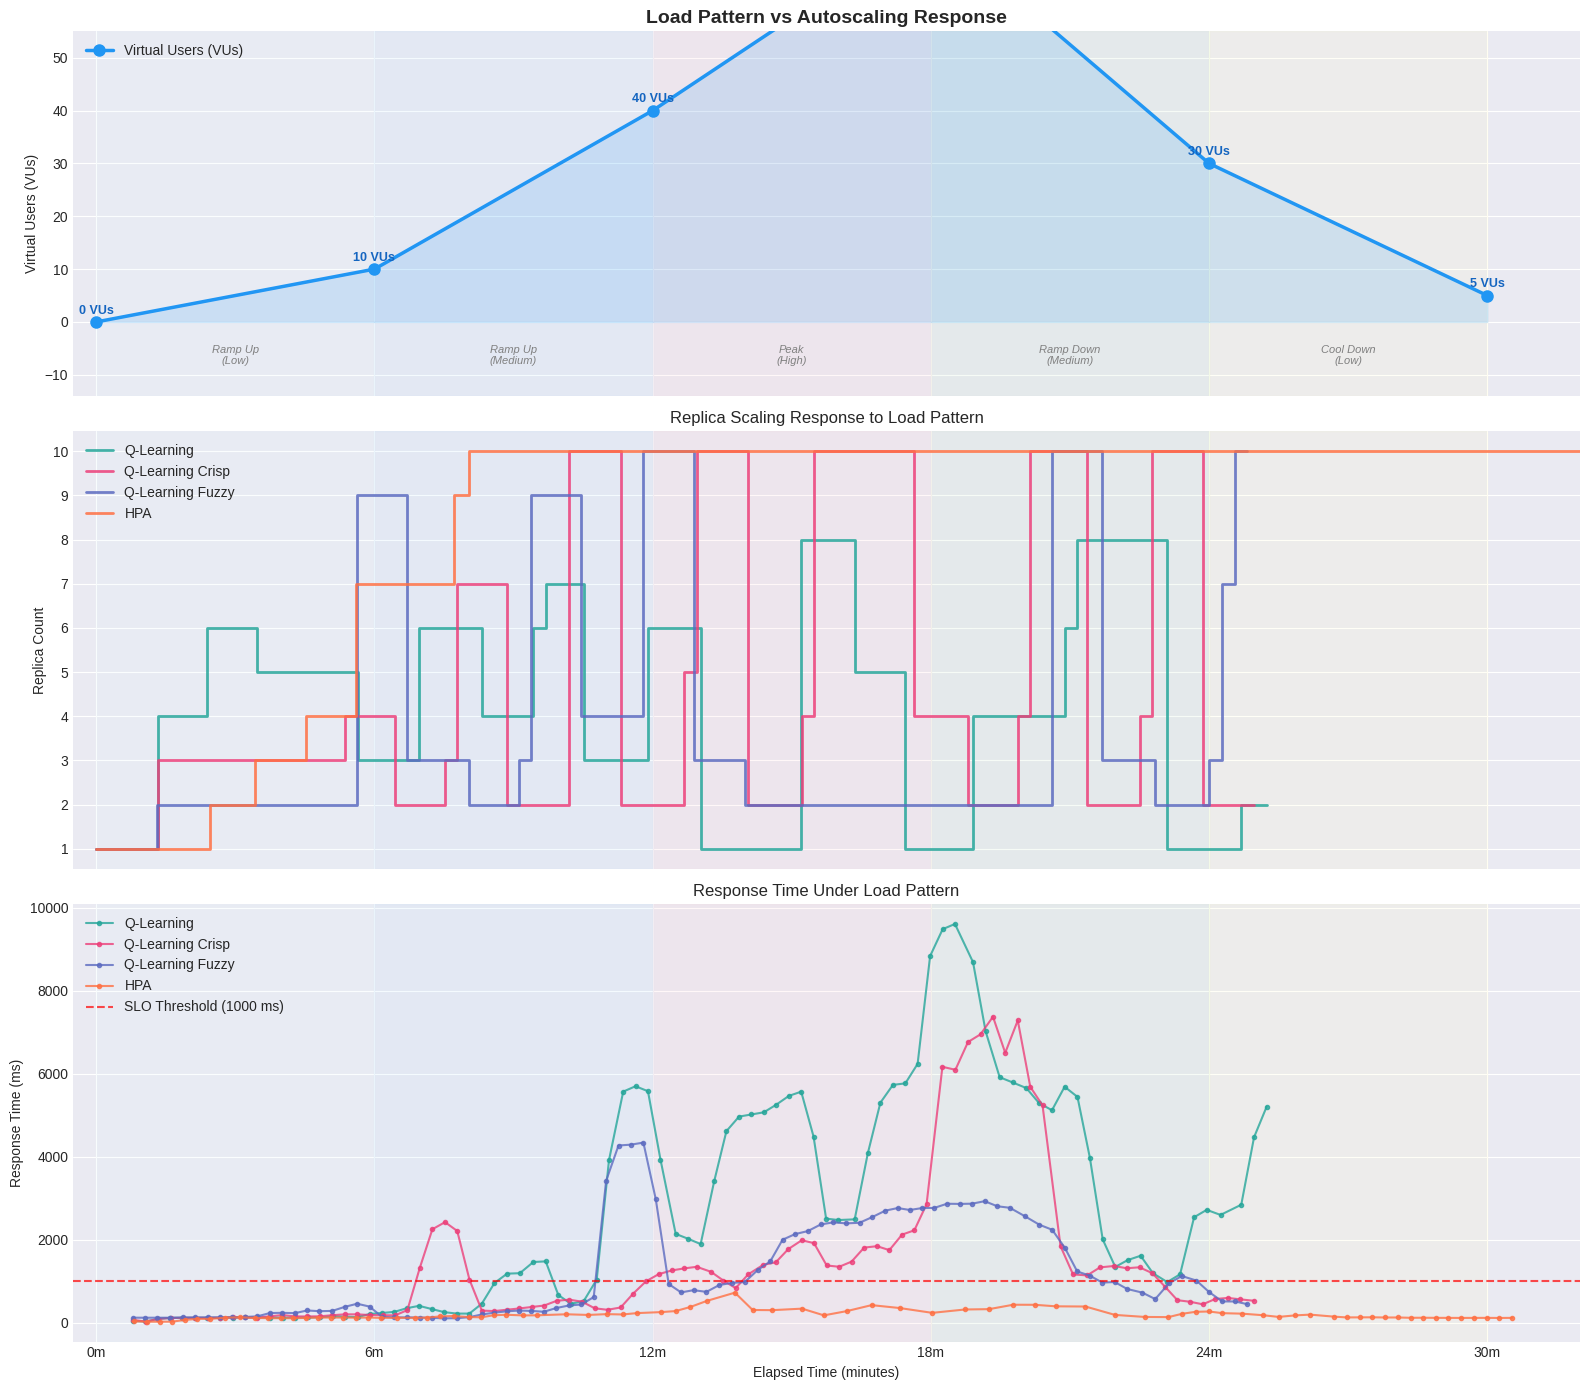


                        LOAD STAGE vs AUTOSCALING RESPONSE SUMMARY                        

  Stage: 0-6m (0->5 VUs)
  Method                  Avg Replica  Avg RT (ms)  Max RT (ms)  SLO Violations
  ------------------------------------------------------------------------------
  Q-Learning                      4.0        121.9        212.9            0/20
  Q-Learning Crisp                2.7        137.8        203.5            0/20
  Q-Learning Fuzzy                2.4        211.6        458.7            0/20
  HPA                             2.6         95.7        132.8            0/19

  Stage: 6-12m (5->15 VUs)
  Method                  Avg Replica  Avg RT (ms)  Max RT (ms)  SLO Violations
  ------------------------------------------------------------------------------
  Q-Learning                      4.7       1476.3       5698.1            9/22
  Q-Learning Crisp                4.5        739.8       2423.7            6/22
  Q-Learning Fuzzy                5.0        942.0  

In [17]:
# k6 ramping-vus stages (from agent-dipa/load-resource-intensive-ii/k6-test-*.js)
k6_stages = [
    {"duration_min": 6, "target": 10},
    {"duration_min": 6, "target": 40},
    {"duration_min": 6, "target": 75},
    {"duration_min": 6, "target": 30},
    {"duration_min": 6, "target": 5},
]

# Build k6 load pattern time series
k6_times_min = [0]
k6_vus = [0]  # startVUs = 0
t = 0
for stage in k6_stages:
    t += stage["duration_min"]
    k6_times_min.append(t)
    k6_vus.append(stage["target"])

# Convert elapsed_s to elapsed_min for testing data
for k in METHODS:
    dfs[k]['elapsed_min'] = dfs[k]['elapsed_s'] / 60.0

# --- Combined 3-panel figure ---
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True,
                          gridspec_kw={'height_ratios': [1, 1.2, 1.2]})

# Stage colors and labels for background shading (5 stages)
stage_colors = ['#E3F2FD', '#BBDEFB', '#FFCDD2', '#C8E6C9', '#FFF9C4']
stage_labels = ['Ramp Up\n(Low)', 'Ramp Up\n(Medium)', 'Peak\n(High)', 'Ramp Down\n(Medium)', 'Cool Down\n(Low)']

# Apply stage shading to all panels
for ax in axes:
    for i in range(len(k6_stages)):
        ax.axvspan(k6_times_min[i], k6_times_min[i+1], alpha=0.15, color=stage_colors[i])

# ---- Panel 1: Load Pattern (VUs) ----
ax = axes[0]
ax.plot(k6_times_min, k6_vus, marker='o', linewidth=2.5, color='#2196F3',
        markersize=8, zorder=3, label='Virtual Users (VUs)')
ax.fill_between(k6_times_min, k6_vus, alpha=0.15, color='#2196F3')

# Annotate VU targets
for i, (t_val, v) in enumerate(zip(k6_times_min, k6_vus)):
    offset_y = 6 if v != max(k6_vus) else -12
    ax.annotate(f'{v} VUs', (t_val, v), textcoords='offset points',
                xytext=(0, offset_y), ha='center', fontsize=9, fontweight='bold', color='#1565C0')

# Stage labels at bottom of panel 1
for i in range(len(k6_stages)):
    mid = (k6_times_min[i] + k6_times_min[i+1]) / 2
    ax.text(mid, -8, stage_labels[i], ha='center', fontsize=8, style='italic', color='gray')

ax.set_ylabel('Virtual Users (VUs)')
ax.set_title('Load Pattern vs Autoscaling Response', fontsize=14, fontweight='bold')
ax.set_ylim(-14, 55)
ax.legend(loc='upper left')

# ---- Panel 2: Replica Count ----
ax = axes[1]
for key, df, label in datasets:
    ax.step(df['elapsed_min'], df['replica_state'], where='post', linewidth=2,
            label=label, color=COLORS[key], alpha=0.85)

ax.set_ylabel('Replica Count')
ax.set_title('Replica Scaling Response to Load Pattern')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(loc='upper left')

# ---- Panel 3: Response Time ----
ax = axes[2]
SLO_THRESHOLD = 1000

for key, df, label in datasets:
    mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    ax.plot(df.loc[mask, 'elapsed_min'], df.loc[mask, 'response_time_ms'],
            marker='o', markersize=3, linewidth=1.5, label=label, color=COLORS[key], alpha=0.8)

ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'SLO Threshold ({SLO_THRESHOLD} ms)')
ax.set_xlabel('Elapsed Time (minutes)')
ax.set_ylabel('Response Time (ms)')
ax.set_title('Response Time Under Load Pattern')
ax.legend(loc='upper left')

# Shared x-axis ticks at stage boundaries
for ax in axes:
    ax.set_xticks(k6_times_min)
    ax.set_xticklabels([f'{tt}m' for tt in k6_times_min])
    ax.set_xlim(-0.5, max(k6_times_min) + 2)

plt.tight_layout()
plt.show()

# --- Summary: reaction per stage ---
stage_boundaries = list(zip(k6_times_min[:-1], k6_times_min[1:]))
stage_names = ['0-6m (0->5 VUs)', '6-12m (5->15 VUs)', '12-18m (15->40 VUs)',
               '18-24m (40->15 VUs)', '24-30m (15->5 VUs)']

print(f'\n{"=" * 90}')
print(f'{"LOAD STAGE vs AUTOSCALING RESPONSE SUMMARY":^90}')
print(f'{"=" * 90}')

for stage_name, (t_start, t_end) in zip(stage_names, stage_boundaries):
    print(f'\n  Stage: {stage_name}')
    print(f'  {"Method":<22} {"Avg Replica":>12} {"Avg RT (ms)":>12} {"Max RT (ms)":>12} {"SLO Violations":>15}')
    print(f'  {"-" * 78}')
    for key, df, label in datasets:
        mask = (df['elapsed_min'] >= t_start) & (df['elapsed_min'] < t_end)
        stage_df = df.loc[mask]
        if len(stage_df) == 0:
            print(f'  {label:<22} {"N/A":>12} {"N/A":>12} {"N/A":>12} {"N/A":>15}')
            continue
        avg_rep = stage_df['replica_state'].mean()
        rt_valid = stage_df.loc[stage_df['response_time_ms'].notna() & (stage_df['response_time_ms'] > 0), 'response_time_ms']
        avg_rt = rt_valid.mean() if len(rt_valid) > 0 else 0
        max_rt = rt_valid.max() if len(rt_valid) > 0 else 0
        violations = (rt_valid > SLO_THRESHOLD).sum() if len(rt_valid) > 0 else 0
        total_valid = len(rt_valid)
        viol_str = f'{violations}/{total_valid}' if total_valid > 0 else 'N/A'
        print(f'  {label:<22} {avg_rep:>12.1f} {avg_rt:>12.1f} {max_rt:>12.1f} {viol_str:>15}')

## 6.1.12 Replica Count & Response Time dengan Load Pattern Background

Grafik replica count dan response time untuk keempat metode dengan pola beban k6 (VUs) sebagai background menggunakan dual y-axis.

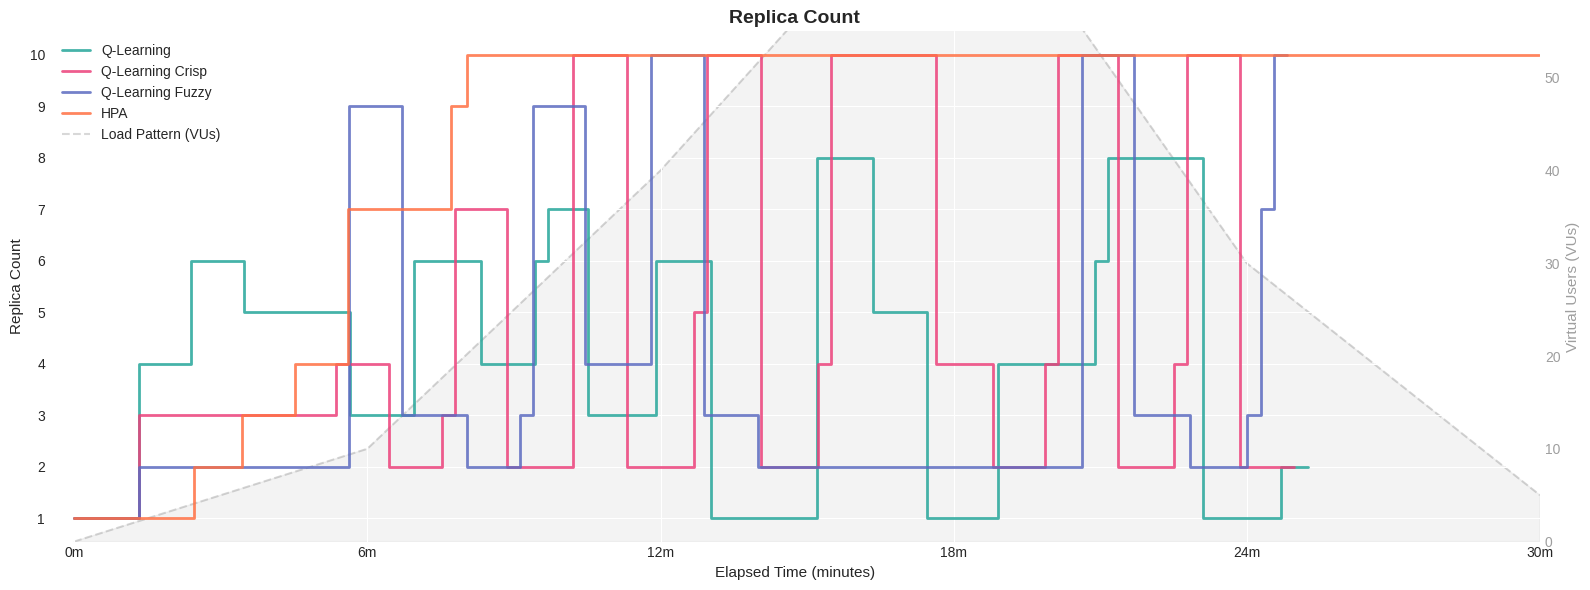

In [18]:
# --- Replica Count with Load Pattern background (twinx) ---
fig, ax1 = plt.subplots(figsize=(16, 6))

# Limit data and stages to first 30 minutes
X_LIMIT_MIN = 30
k6_times_min_30 = [tt for tt in k6_times_min if tt <= X_LIMIT_MIN]
k6_vus_30 = k6_vus[:len(k6_times_min_30)]

# Background: Load pattern (VUs) on secondary y-axis
ax2 = ax1.twinx()
ax2.fill_between(k6_times_min_30, k6_vus_30, alpha=0.12, color='#9E9E9E')
ax2.plot(k6_times_min_30, k6_vus_30, linewidth=1.5, color='#9E9E9E', alpha=0.4,
         linestyle='--', label='Load Pattern (VUs)')
ax2.set_ylabel('Virtual Users (VUs)', color='#9E9E9E', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#9E9E9E', labelsize=10)
ax2.set_ylim(0, 55)

# Foreground: Replica count per method
for key, df, label in datasets:
    mask = df['elapsed_min'] <= X_LIMIT_MIN
    ax1.step(df.loc[mask, 'elapsed_min'], df.loc[mask, 'replica_state'], where='post', linewidth=2,
             label=label, color=COLORS[key], alpha=0.85)

ax1.set_xlabel('Elapsed Time (minutes)', fontsize=11)
ax1.set_ylabel('Replica Count', fontsize=11)
ax1.set_title('Replica Count', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Ensure foreground is on top
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

ax1.set_xticks(k6_times_min_30)
ax1.set_xticklabels([f'{tt}m' for tt in k6_times_min_30])
ax1.set_xlim(-0.5, X_LIMIT_MIN)

plt.tight_layout()
plt.show()

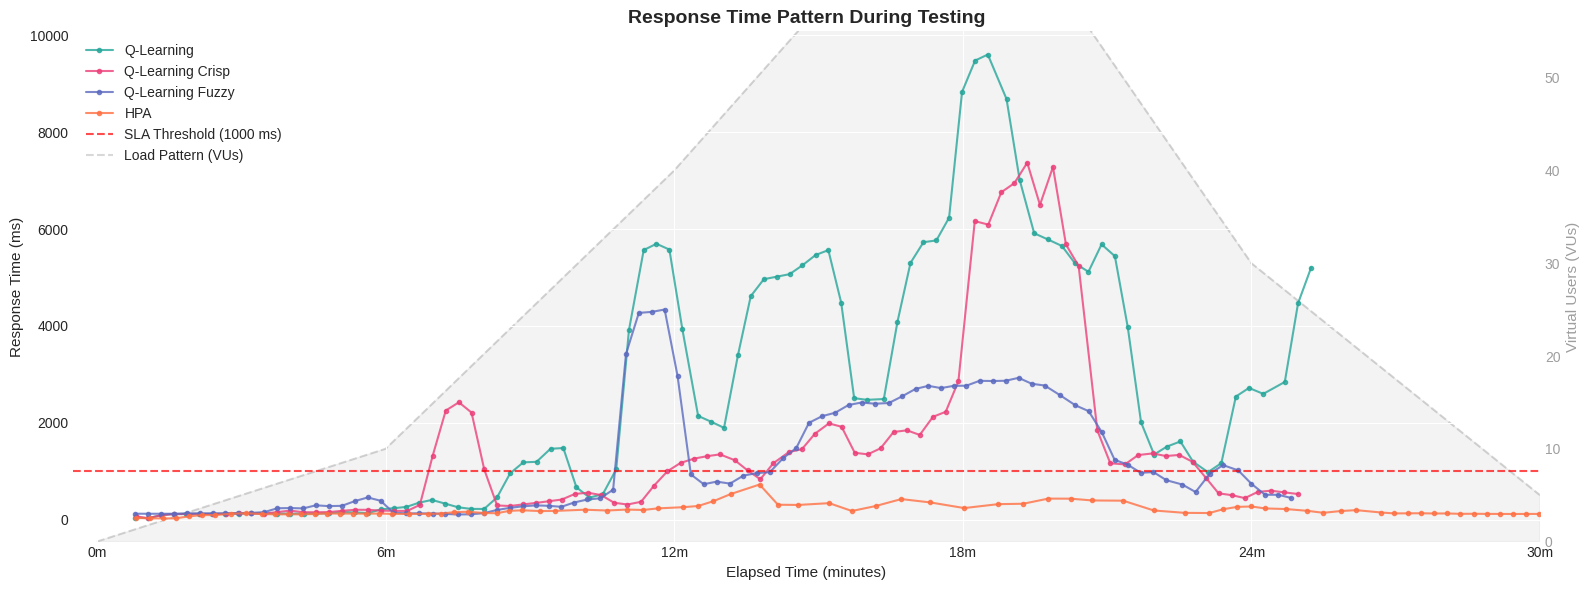

In [19]:
# --- Response Time with Load Pattern background (twinx) ---
fig, ax1 = plt.subplots(figsize=(16, 6))

# Limit data and stages to first 30 minutes
X_LIMIT_MIN = 30
k6_times_min_30 = [tt for tt in k6_times_min if tt <= X_LIMIT_MIN]
k6_vus_30 = k6_vus[:len(k6_times_min_30)]

# Background: Load pattern (VUs) on secondary y-axis
ax2 = ax1.twinx()
ax2.fill_between(k6_times_min_30, k6_vus_30, alpha=0.12, color='#9E9E9E')
ax2.plot(k6_times_min_30, k6_vus_30, linewidth=1.5, color='#9E9E9E', alpha=0.4,
         linestyle='--', label='Load Pattern (VUs)')
ax2.set_ylabel('Virtual Users (VUs)', color='#9E9E9E', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#9E9E9E', labelsize=10)
ax2.set_ylim(0, 55)

# Foreground: Response time per method
SLO_THRESHOLD = 1000
for key, df, label in datasets:
    mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0) & (df['elapsed_min'] <= X_LIMIT_MIN)
    ax1.plot(df.loc[mask, 'elapsed_min'], df.loc[mask, 'response_time_ms'],
             marker='o', markersize=3, linewidth=1.5, label=label, color=COLORS[key], alpha=0.8)

ax1.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'SLA Threshold ({SLO_THRESHOLD} ms)')

ax1.set_xlabel('Elapsed Time (minutes)', fontsize=11)
ax1.set_ylabel('Response Time (ms)', fontsize=11)
ax1.set_title('Response Time Pattern During Testing', fontsize=14, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Ensure foreground is on top
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

ax1.set_xticks(k6_times_min_30)
ax1.set_xticklabels([f'{tt}m' for tt in k6_times_min_30])
ax1.set_xlim(-0.5, X_LIMIT_MIN)

plt.tight_layout()
plt.show()

## 6.1.13 Analisis Pelanggaran SLA per Load Stage (Response Time > 1000ms)

Jumlah dan persentase pelanggaran SLA per load stage selama pengujian untuk keempat metode autoscaling.

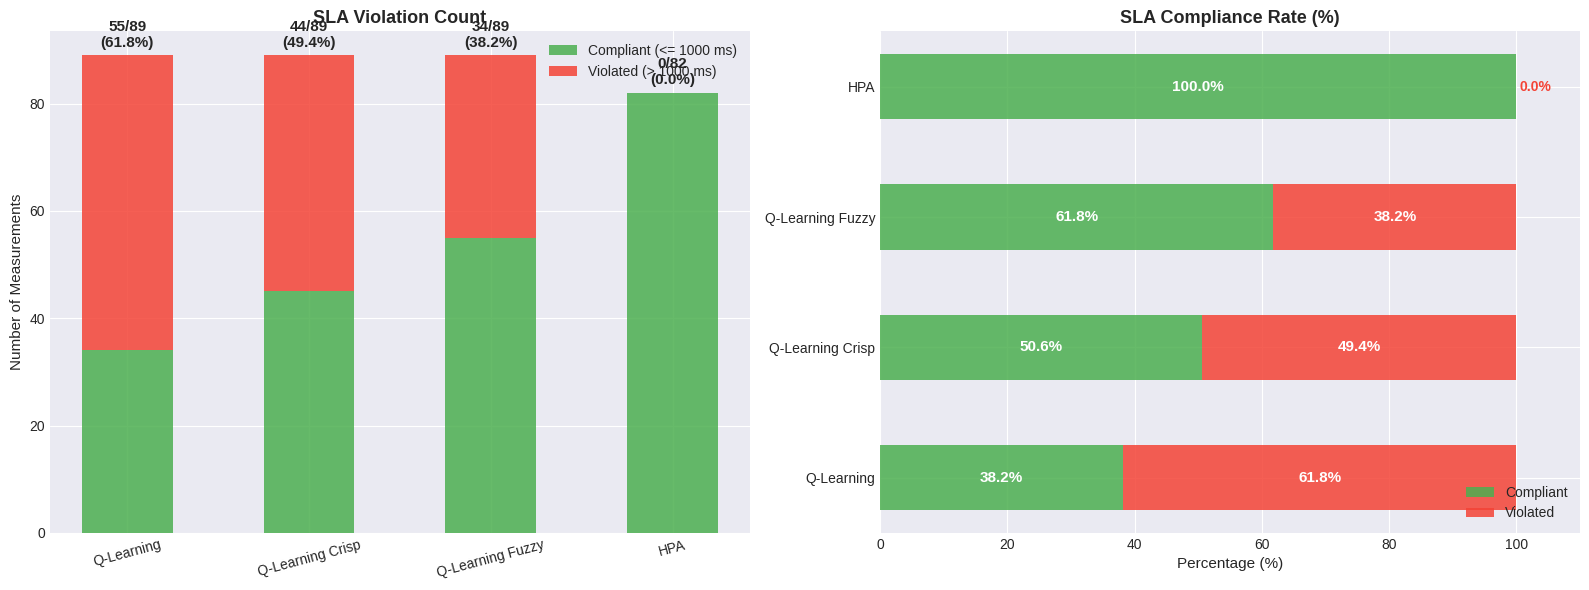

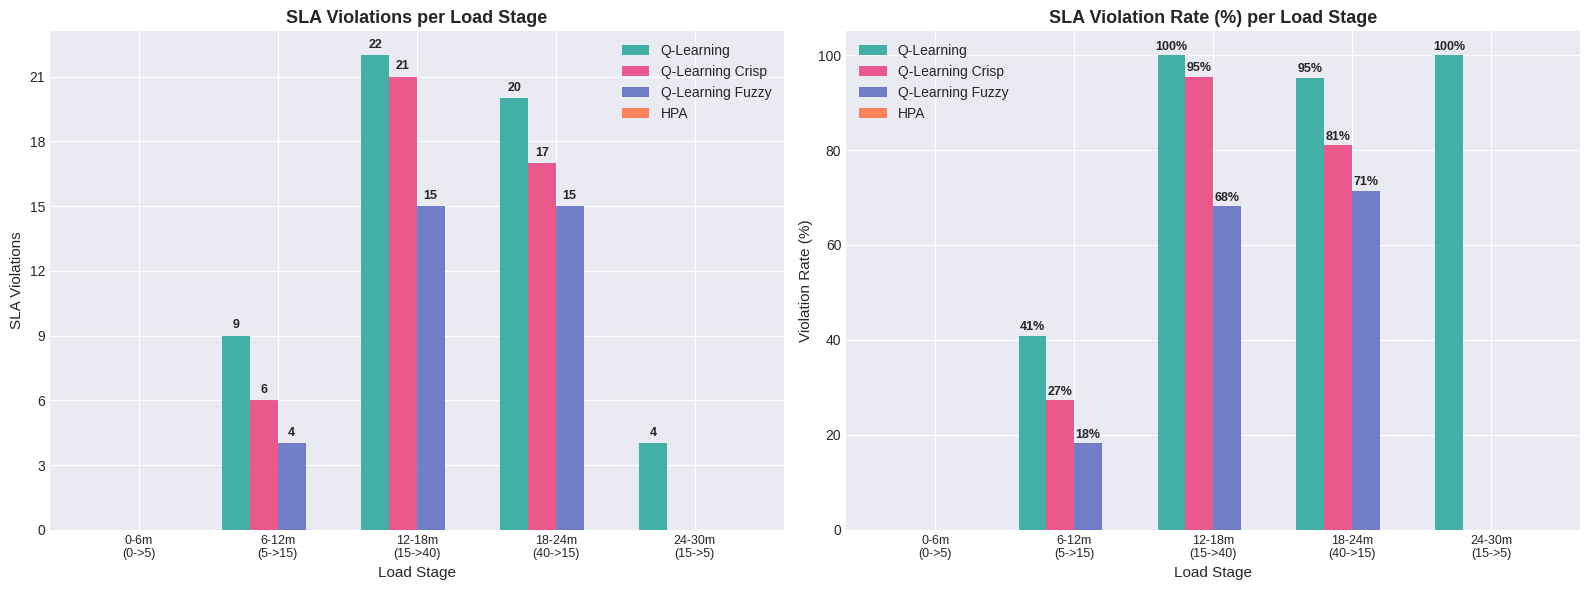


                   SLA VIOLATION SUMMARY (Threshold: 1000 ms)                   

Method                    Total  Compliant   Violated  Violation %
-----------------------------------------------------------------
Q-Learning                   89         34         55        61.8%
Q-Learning Crisp             89         45         44        49.4%
Q-Learning Fuzzy             89         55         34        38.2%
HPA                          82         82          0         0.0%

                              SLA Violations per Load Stage                               
------------------------------------------------------------------------------------------
Stage                          Q-Learning   Q-Learning Crisp   Q-Learning Fuzzy                HPA
------------------------------------------------------------------------------------------
0-6m (0->5 VUs)          0/20 (   0%)   0/20 (   0%)   0/20 (   0%)   0/19 (   0%)
6-12m (5->15 VUs)        9/22 (  41%)   6/22 (  27%)   4/22 

In [20]:
SLA_THRESHOLD = 1000  # ms (from .env MAX_RESPONSE_TIME)

datasets_sla = datasets

# --- 1) Overall SLA comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sla_stats = {}
for key, df, label in datasets_sla:
    valid = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    total = valid.sum()
    violated = (df.loc[valid, 'response_time_ms'] > SLA_THRESHOLD).sum()
    compliant = total - violated
    pct_violated = violated / total * 100 if total > 0 else 0
    sla_stats[label] = {'total': total, 'violated': violated, 'compliant': compliant,
                         'pct_violated': pct_violated, 'pct_compliant': 100 - pct_violated}

# Left: Stacked bar chart (count)
ax = axes[0]
methods = list(sla_stats.keys())
compliant_vals = [sla_stats[m]['compliant'] for m in methods]
violated_vals = [sla_stats[m]['violated'] for m in methods]
total_vals = [sla_stats[m]['total'] for m in methods]

x = np.arange(len(methods))
width = 0.5
ax.bar(x, compliant_vals, width, label=f'Compliant (<= {SLA_THRESHOLD} ms)', color='#4CAF50', alpha=0.85)
ax.bar(x, violated_vals, width, bottom=compliant_vals, label=f'Violated (> {SLA_THRESHOLD} ms)', color='#F44336', alpha=0.85)

for i in range(len(methods)):
    v = violated_vals[i]
    t = total_vals[i]
    pct = v / t * 100 if t > 0 else 0
    ax.text(i, t + 1, f'{v}/{t}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Measurements', fontsize=11)
ax.set_title('SLA Violation Count', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=10, rotation=15)
ax.legend(fontsize=10)

# Right: Horizontal percentage bar
ax = axes[1]
pct_c = [sla_stats[m]['pct_compliant'] for m in methods]
pct_v = [sla_stats[m]['pct_violated'] for m in methods]

ax.barh(x, pct_c, height=0.5, label='Compliant', color='#4CAF50', alpha=0.85)
ax.barh(x, pct_v, height=0.5, left=pct_c, label='Violated', color='#F44336', alpha=0.85)

for i in range(len(methods)):
    if pct_c[i] > 15:
        ax.text(pct_c[i] / 2, i, f'{pct_c[i]:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    if pct_v[i] > 5:
        ax.text(pct_c[i] + pct_v[i] / 2, i, f'{pct_v[i]:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    else:
        ax.text(100.5, i, f'{pct_v[i]:.1f}%', ha='left', va='center', fontsize=10, fontweight='bold', color='#F44336')

ax.set_xlabel('Percentage (%)', fontsize=11)
ax.set_title('SLA Compliance Rate (%)', fontsize=13, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(methods, fontsize=10)
ax.set_xlim(0, 110)
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

# --- 2) SLA violations per load stage ---
stage_boundaries_min = list(zip(k6_times_min[:-1], k6_times_min[1:]))
stage_names_short = ['0-6m\n(0->5)', '6-12m\n(5->15)', '12-18m\n(15->40)',
                     '18-24m\n(40->15)', '24-30m\n(15->5)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_stage = np.arange(len(stage_names_short))
n = len(datasets_sla)
width = 0.8 / n

# Left: violation count per stage
ax = axes[0]
for i, (key, df, label) in enumerate(datasets_sla):
    viol_per_stage = []
    for t_start, t_end in stage_boundaries_min:
        mask = (df['elapsed_min'] >= t_start) & (df['elapsed_min'] < t_end)
        valid = df.loc[mask, 'response_time_ms'].notna() & (df.loc[mask, 'response_time_ms'] > 0)
        viol = (df.loc[mask].loc[valid, 'response_time_ms'] > SLA_THRESHOLD).sum()
        viol_per_stage.append(viol)
    bars = ax.bar(x_stage + (i - (n - 1) / 2) * width, viol_per_stage, width, label=label, color=COLORS[key], alpha=0.85)
    for bar, val in zip(bars, viol_per_stage):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
                    str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Load Stage', fontsize=11)
ax.set_ylabel('SLA Violations', fontsize=11)
ax.set_title('SLA Violations per Load Stage', fontsize=13, fontweight='bold')
ax.set_xticks(x_stage)
ax.set_xticklabels(stage_names_short, fontsize=9)
ax.legend(fontsize=10)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Right: violation percentage per stage
ax = axes[1]
for i, (key, df, label) in enumerate(datasets_sla):
    pct_per_stage = []
    for t_start, t_end in stage_boundaries_min:
        mask = (df['elapsed_min'] >= t_start) & (df['elapsed_min'] < t_end)
        valid_mask = df.loc[mask, 'response_time_ms'].notna() & (df.loc[mask, 'response_time_ms'] > 0)
        total = valid_mask.sum()
        viol = (df.loc[mask].loc[valid_mask, 'response_time_ms'] > SLA_THRESHOLD).sum()
        pct = viol / total * 100 if total > 0 else 0
        pct_per_stage.append(pct)
    bars = ax.bar(x_stage + (i - (n - 1) / 2) * width, pct_per_stage, width, label=label, color=COLORS[key], alpha=0.85)
    for bar, val in zip(bars, pct_per_stage):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Load Stage', fontsize=11)
ax.set_ylabel('Violation Rate (%)', fontsize=11)
ax.set_title('SLA Violation Rate (%) per Load Stage', fontsize=13, fontweight='bold')
ax.set_xticks(x_stage)
ax.set_xticklabels(stage_names_short, fontsize=9)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# --- 3) Summary Table ---
print(f'\n{"=" * 80}')
print(f'{"SLA VIOLATION SUMMARY (Threshold: " + str(SLA_THRESHOLD) + " ms)":^80}')
print(f'{"=" * 80}')
print(f'\n{"Method":<22} {"Total":>8} {"Compliant":>10} {"Violated":>10} {"Violation %":>12}')
print(f'{"-" * 65}')
for label in methods:
    s = sla_stats[label]
    print(f'{label:<22} {s["total"]:>8} {s["compliant"]:>10} {s["violated"]:>10} {s["pct_violated"]:>11.1f}%')

print(f'\n{"SLA Violations per Load Stage":^90}')
print(f'{"-" * 90}')
stage_names_full = ['0-6m (0->5 VUs)', '6-12m (5->15 VUs)', '12-18m (15->40 VUs)',
                    '18-24m (40->15 VUs)', '24-30m (15->5 VUs)']
header = f'{"Stage":<22}'
for key, df, label in datasets_sla:
    header += f' {label:>18}'
print(header)
print(f'{"-" * 90}')
for stage_name, (t_start, t_end) in zip(stage_names_full, stage_boundaries_min):
    row = f'{stage_name:<22}'
    for key, df, label in datasets_sla:
        mask = (df['elapsed_min'] >= t_start) & (df['elapsed_min'] < t_end)
        valid_mask = df.loc[mask, 'response_time_ms'].notna() & (df.loc[mask, 'response_time_ms'] > 0)
        total = valid_mask.sum()
        viol = (df.loc[mask].loc[valid_mask, 'response_time_ms'] > SLA_THRESHOLD).sum()
        pct = viol / total * 100 if total > 0 else 0
        row += f' {viol:>3}/{total:<3}({pct:>4.0f}%)'
    print(row)